In [39]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phyloDNN import seq_utils as sq
import argparse
import pandas as pd

import re
from joblib import Parallel, delayed

import numpy as np
import matplotlib.pyplot as plt


quantile1 = lambda x: x.quantile(0.25)
quantile2 = lambda x: x.quantile(0.75)

def plot_errorbar(df):
    g=df.groupby(df.index)
    fig, ax = plt.subplots(figsize=(12, 8))
    # 2. Group the DataFrame by the numeric index and calculate mean and standard deviation
    for c in df.columns:
        grouped_data = g.agg(
            mean=(c, 'mean'),
            std=(c, 'std'),
            q1=(c,quantile1),
            q2=(c, quantile2)
        )
        # print(grouped_data.q2,grouped_data['mean'])
        iqr = np.array(
        [
            grouped_data.q2-grouped_data['mean'],
            grouped_data['mean']-grouped_data.q1
        ])
        iqr = np.maximum(iqr,0)
        # print(iqr,iqr.min())
        # quantiles = g.quantile([0.25, 0.75]).unstack()

        # 3. Plot the line plots with error bars on the same figure

        ax.errorbar(
            x=grouped_data.index,
            y=grouped_data['mean'],
            yerr=iqr,#grouped_data['std'],
            # fmt='-o',
            capsize=5,
            label=c
        )
        # 4. Add labels, title, and a legend
    ax.set_xlabel('Sequence Length')
    ax.set_ylabel(r'$d_{RF}$')
    ax.legend()
    ax.grid(True)
    
def plot(p, alg='rf'):
    p= (p
        .rename(columns=keep)
        .melt(
            # id_vars=['filenames', 'tree'],
            value_vars=keep.values(),
            var_name="model",
            value_name="statistic",
    ))
    
    sns.violinplot(data=p, x="model", y="statistic", cut=0)
    plt.title(r"$d_{wRF}$" if alg == "wrf" else r"$d_{RF}$")
    plt.xticks(rotation=90)
    plt.xlabel("Model")
    plt.ylabel(r"$d_{WRF}$" if alg == "wrf" else r"$d_{RF}$")
    plt.tight_layout()

## Violin Error Plots

In [ ]:
seqdir = 'hky_f_20' #
seqdir = 'hky_20' #
# seqdir = 'jc_20' #
# seqdir = 'lg_gc_20'
# seqdir = 'lg_indel_20'
try:
    s= f'../data/{seqdir}/trees_bionj_all_preds.tsv.gz'
    preds = pd.read_csv(s,sep='\t')
except:
    s=f'../data/phyloDNN/test/{seqdir}/trees_bionj_all_preds.tsv.gz'
    preds = pd.read_csv(s,sep='\t')
sorted(preds.columns)
pd.set_option('display.max_columns', None)
preds[[c for c in preds if c.startswith('rf')]].describe()
# preds.query(f'rf_m_iqtree == 0 | rf_m_iqtree <= {ham} ')[[c for c in preds if c.startswith('rf')]].describe()

In [ ]:
pd.set_option('display.max_rows', None)
preds.query('rf_m_iqtree>0')[['filenames','rf_m_iqtree']].sort_values('rf_m_iqtree')
preds[[c for c in preds if c.startswith('rf')]].iloc[33] # hard for iqtree -> nobody beats hamming?
preds.iloc[33]

In [ ]:
preds[[c for c in preds if c.startswith('rf')]].describe()

In [ ]:
keep = { 
    # 'rf_m_hammingnet_e':r'$d_H$',
    'rf_m_jcnet_prot_e':r'$d_{JC}$',
        'rf_m_seq1_f64_h4':'Site-Invariant-S',
        'rf_m_seq1b_f64_i7_h4':'Full-Invariant-S',
         'rf_m_row_only':'Site-Attention-P',
        'rf_m_s3cr_p3r_mae':'Hybrid-Attention-SP',
        'rf_m_s3p3_mae':'Full-Attention-SP',
         'rf_m_pformer':'Phyloformer',
         'rf_m_iqtree':'IQTREE', 
        }

if 'jc' in seqdir:
    keep = {
            'm_jcnet_e_m':r'$d_{JC}$',
        'rf_m_seq1_f128x7_h4':'Site-Invariant-S',
         'rf_m_row_only':'Site-Attention-P',
        'rf_m_s3cr_p3r_mae':'Hybrid-Attention-SP',
         'rf_m_iqtree':'IQTREE', 
    }
elif 'hky' in seqdir:
    keep = {
            'm_jcnet_e_m':r'$d_{JC}$',
        'rf_m_seq1_f128x7_h4':'Site-Invariant-S',
         'rf_m_row_only':'Site-Attention-P',
        'rf_m_s3cr_p3r_mae':'Hybrid-Attention-SP',
         'rf_m_iqtree':'IQTREE', 
    }  
elif 'indel' in seqdir:
    keep = {
            'm_jcnet_e_m':r'$d_{JC}$',
        'rf_m_seq1b_f64_i7_h4_conv3x3':'Site-Invariant-S',
         'rf_m_row_only_pos':'Site-Attention-P',
        'rf_m_s3cr_p3r_pos':'Hybrid-Attention-SP',
        'rf_m_s3p3_pos':'Full-Attention-SP',
         'rf_m_iqtree':'IQTREE', 
    }  

In [ ]:
ham = 'rf_m_hammingnet_e' if 'rf_m_hammingnet_e' in preds else 'rf_m_hamming'
print(ham)


In [ ]:
(preds[ham] - preds['rf_m_iqtree']).hist(bins=50)
preds.columns

In [ ]:
alg='rf'

p = plot(
    preds[keep.keys()]
)
plt.savefig(
            f"figs/final_{seqdir}_{alg}.png",
            bbox_inches="tight",
        )
preds.columns

In [ ]:
alg='rf'

p = plot(
    (preds.query(f'{ham} ==0.5 | rf_m_iqtree <=  {ham}')[keep.keys()])
)
plt.savefig(
            f"figs/final_{seqdir}_{alg}_not_hard.png",
            bbox_inches="tight",
        )

In [ ]:
preds[[c for c in preds if c.startswith('rf')]].hist()
plt.tight_layout()

In [ ]:
alg='wrf'
plot(
    (preds[['w'+k for k in keep]]
        .rename(columns = lambda c:c.replace('wrf','rf'))
    ),
    alg=alg
) 
     #.query('rf_m_jcnet_enet_e<.3'))

In [ ]:
! for d in hky_20 hky_f_20 jc_20 lg_indel_20 lg_gc_20; do mkdir -p data/$d; rsync -avPr  bkrosenz@quartz
.uits.iu.edu:/N/project/phyloML/data/phyloDNN/test/$d/*tsv.gz data/$d;done

In [ ]:
alg='rf'
p = plot(
    (preds.query(f'rf_m_iqtree > 0.5 | rf_m_iqtree >  {ham}')[keep.keys()])
)
plt.savefig(
            f"figs/final_{seqdir}_{alg}_hard.png",
            bbox_inches="tight",
        )

In [ ]:
preds[keep.keys()].describe()

## Consistency

In [10]:
keep = { 
    # 'hammingnet_e':r'$d_H$',
        'seq1_f64_h4':'Site-Invariant-S',
        'seq1b_f64_i7_h4':'Full-Invariant-S',
         'row_only':'Site-Attention-P',
        's3cr_p3r_mae':'Hybrid-Attention-SP',
        's3p3_mae':'Full-Attention-SP',
          'seq' : 'Full-Attention-S',
        }

In [11]:
p=Path('/N/project/phyloML/data/phyloDNN/test/lg_gc_20_long')
dfs = {s.stem[:-3].replace('predictions_',''):pd.read_pickle(s).set_index('filenames') for s in p.rglob('*pd.gz')}
# dfs = {k:v for k,v in dfs.items() if k in keep}
dfs.keys()

dict_keys(['seq3b_f256x4_h4', 'seq1b_f64_i3x256_h4', 'seq', 'seq1_f64_l21', 'seq1_f64x2', 'seq1b_f64_i7_h4', 'seq1b_f64_h4', 's3cr_p3r_mae', 'seq1_f64_h4', 'seq1b_f256x4_h4', 'seq1_f64', 'seq1b_f64_h4_i7_l21', 'row_only', 's3p3_mae', 'seq1b_f64_l21', 'seq6b_f256x4_h4'])

In [18]:
!ls /N/project/phyloML/data/phyloDNN/test/lg_gc_20_long/6_20_tips*

/N/project/phyloML/data/phyloDNN/test/lg_gc_20_long/6_20_tips_1000.phy
/N/project/phyloML/data/phyloDNN/test/lg_gc_20_long/6_20_tips_2000.phy
/N/project/phyloML/data/phyloDNN/test/lg_gc_20_long/6_20_tips_250.phy
/N/project/phyloML/data/phyloDNN/test/lg_gc_20_long/6_20_tips_4000.phy
/N/project/phyloML/data/phyloDNN/test/lg_gc_20_long/6_20_tips_500.phy
/N/project/phyloML/data/phyloDNN/test/lg_gc_20_long/6_20_tips_6000.phy


In [23]:
rx = re.compile('_tips_(\d+)')

trees = pd.read_csv('/N/project/phyloML/data/phyloDNN/test/trees_20.tsv',sep='\s',header=None,index_col=0)

tree_name=re.compile('(.*)_\d+$')
def get_rf(row):
    tname = tree_name.findall(row.name)[0]
    tstr = trees.loc[tname].iloc[0]
    # print(tname)
    return sq.rf_distance(tstr,row.trees_bionj)

rfs = {d:dfs[d].drop('63_20_tips', errors='ignore').apply(get_rf,axis=1) for d in dfs}

rfs=pd.DataFrame(rfs).dropna(axis=1)
rfs.index=rfs.index.map(lambda s: int(rx.findall(s)[0]))


/tmp/ipykernel_1394627/3900939662.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  trees = pd.read_csv('/N/project/phyloML/data/phyloDNN/test/trees_20.tsv',sep='\s',header=None,index_col=0)


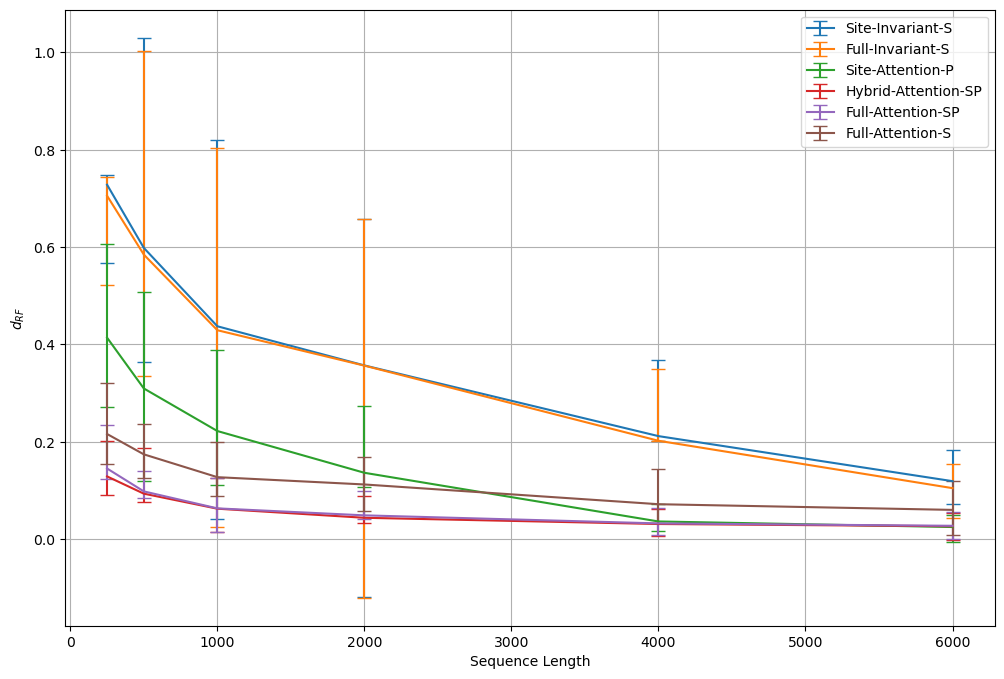

In [40]:

rfs.sort_index(inplace=True)
# plt.xlabel('Sequence Length')
# plt.ylim([0,.45])
plot_errorbar(rfs[keep.keys()].rename(columns=keep))
plt.savefig(f"figs/seqlens_500.png")

In [45]:
rfs.to_csv('data/rfs_v_seqlen.csv.gz')

In [ ]:

# Sample Data
data = {'Category': ['A', 'A', 'B', 'B', 'A', 'B'],
        'Subcategory': ['X', 'Y', 'X', 'Y', 'X', 'Y'],
        'Value': [10, 12, 15, 18, 11, 16],
        'Error_Measure': [1, 1.5, 2, 2.5, 1.2, 2.1]} # Represents standard deviation or SEM

df = pd.DataFrame(data)

# Group by Category and Subcategory, calculate mean and standard deviation
grouped_data = df.groupby(['Category', 'Subcategory']).agg(
    mean_value=('Value', 'mean'),
    std_value=('Error_Measure', 'mean') # Use mean of Error_Measure for simplicity, or calculate SEM
)

# Pivot to get data in the correct format for grouped bar plot
plot_data = grouped_data['mean_value'].unstack()
error_data = grouped_data['std_value'].unstack()

# Plot the grouped bar chart with error bars
plot_data.plot(kind='bar', yerr=error_data, rot=0, figsize=(8, 5))
plt.title('Grouped Bar Plot with Error Bars')
plt.xlabel('Category')
plt.ylabel('Mean Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

          mean       std
Category                
A         10.5  1.290994
B         14.5  1.290994


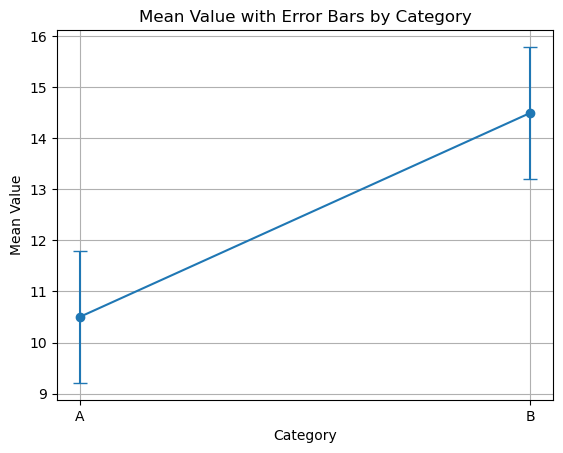

In [26]:

# Create a sample DataFrame
data = {'Category': ['A', 'A', 'B', 'B', 'A', 'B', 'A', 'B'],
        'Value': [10, 12, 15, 13, 11, 16, 9, 14]}
df = pd.DataFrame(data)

# Group by 'Category' and calculate mean and standard deviation
grouped_data = df.groupby('Category')['Value'].agg(['mean', 'std'])
print(grouped_data)
plt.errorbar(x=grouped_data.index,
             y=grouped_data['mean'],
             yerr=grouped_data['std'],
             fmt='-o',  # Line with markers
             capsize=5) # Size of the error bar caps

plt.xlabel('Category')
plt.ylabel('Mean Value')
plt.title('Mean Value with Error Bars by Category')
plt.grid(True)
plt.show()

## Scalability
Redo this once all the predictions have finished.

In [41]:
p=Path('/N/project/phyloML/data/phyloDNN/test/')
lengths = [20,40,60,80,100]
keep = { 
    # 'hammingnet_e':r'$d_H$',
        'seq1_f64_h4':'Site-Invariant-S',
        'seq1b_f64_i7_h4':'Full-Invariant-S',
         'row_only':'Site-Attention-P',
        's3cr_p3r_mae':'Hybrid-Attention-SP',
        's3p3_mae':'Full-Attention-SP',
  'seq' : 'Full-Attention-S',
        }

models = list(keep.keys())


rx = re.compile('_tips_(\d+)')

tree_name=re.compile('(.*)_\d+$')

def f( dname, df):
    distances = df.apply(get_rf,axis=1).agg(('mean', quantile1, quantile2))
    df = pd.DataFrame(
        distances.values,
        index=['Mean','Q1','Q2'],
        columns=[dname]
    )
    return df.T


def read_pd(s):
    df =  pd.read_pickle(s).set_index('filenames')
    s = s.stem[:-3].replace('predictions_','')
    if 'trees_bionj' in df:
        return s,df['trees_bionj'].to_frame()
    return None

In [42]:
m = {}


for l in lengths:
    
    trees = pd.read_csv(
        f'/N/project/phyloML/data/phyloDNN/test/trees_{l}.tsv',
        sep='\s',header=None,index_col=0)
    
    def get_rf(row):
        tstr = trees.loc[row.name].iloc[0]
        return sq.rf_distance(tstr,row.trees_bionj)

    with Parallel(4) as parallel:
        dfs = parallel(
            delayed(read_pd)(s)
                for s in p.rglob(f'lg_gc_{l}/predict*pd.gz')
        )
        dfs = dict(filter(None, dfs))
        dfs = parallel(
                delayed(f)(d, dfs[d]) for d in dfs
        )
    if not dfs:
        print(l)
        continue
    m[l] = pd.concat(dfs)
m=pd.concat(m.values(), keys=m.keys()).loc[pd.IndexSlice[:,models], :]
# dfs = {k:v for k,v in dfs.items() if k in keep}

/tmp/ipykernel_1394627/3562530503.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  trees = pd.read_csv(
/N/project/phyloML/app/Quartz/miniconda3/envs/p311/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/tmp/ipykernel_1394627/3562530503.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  trees = pd.read_csv(
/tmp/ipykernel_1394627/3562530503.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' e

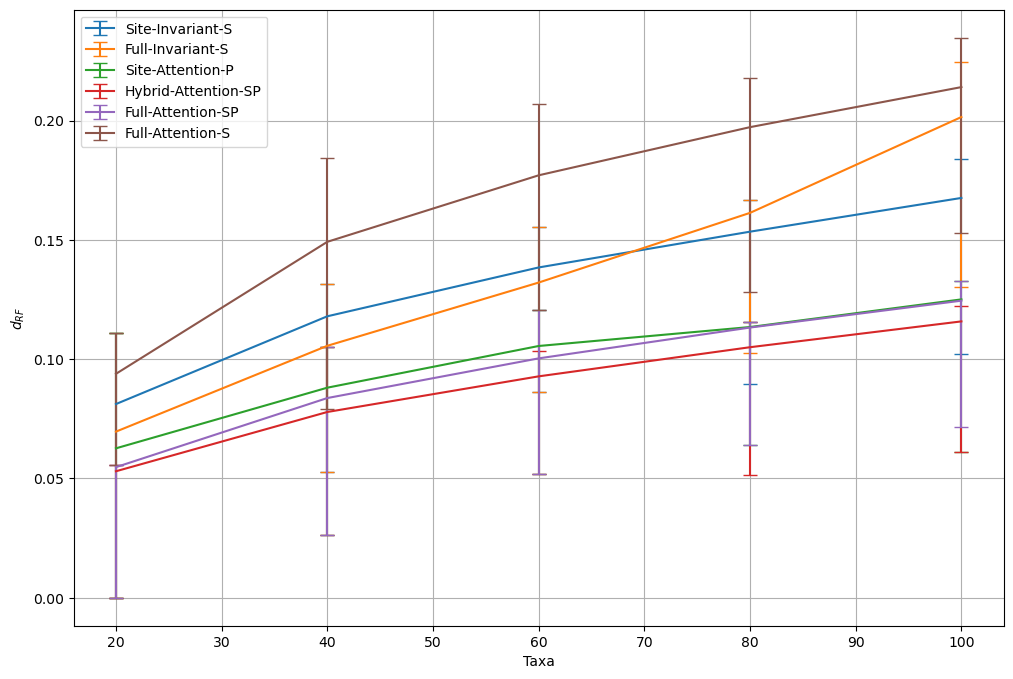

In [43]:
# m=m

fig, ax = plt.subplots(figsize=(12, 8))
e1 = (m.Mean-m.Q1).unstack()
e1[e1<0]=0
e2 = (m.Q2-m.Mean).unstack()
df = m.Mean.unstack()

for c in df.columns:
    print()
    ax.errorbar(
        x=df.index,
        y=df[c],
        yerr=np.array([e1[c],e2[c]]),#grouped_data['std'],
        # fmt='-o',
        capsize=5,
        label=keep[c]
    )
    # 4. Add labels, title, and a legend
ax.set_xlabel('Taxa')
ax.set_ylabel(r'$d_{RF}$')
ax.legend()
ax.grid(True)
plt.savefig(f"figs/taxa_1000.png")

In [44]:
m.to_csv('data/ntaxa_vdrf.csv.gz')

In [46]:
m

,,Mean,Q1,Q2
20,seq1_f64_h4,0.081167,0.000000,0.111111
40,seq1_f64_h4,0.117947,0.052632,0.131579
60,seq1_f64_h4,0.138414,0.086207,0.155172
80,seq1_f64_h4,0.153410,0.089744,0.166667
100,seq1_f64_h4,0.167551,0.102041,0.183673
20,seq1b_f64_i7_h4,0.069611,0.000000,0.111111
40,seq1b_f64_i7_h4,0.105579,0.052632,0.131579
60,seq1b_f64_i7_h4,0.132086,0.086207,0.155172
80,seq1b_f64_i7_h4,0.161295,0.102564,0.166667
100,seq1b_f64_i7_h4,0.201459,0.130102,0.224490
